## Student Performance Indicator


#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

### 2.1 Import Data and Required Packages
####  Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

#### Import the CSV Data as Pandas DataFrame

In [2]:
df = pd.read_csv('data/stud.csv')

#### Show Top 5 Records

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Shape of the dataset

In [5]:
df.shape

(1000, 8)

### 2.2 Dataset information

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [6]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

#### There are no missing values in the data set

### 3.2 Check Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

#### There are no duplicates  values in the data set

### 3.3 Check data types

In [8]:
# Check Null and Dtypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


### 3.4 Checking the number of unique values of each column

In [9]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### 3.5 Check statistics of data set

In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From the above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

### 3.7 Exploring Data

In [11]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [12]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:  ",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in'parental level of education' variable:",end=" " )
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test_preparation_course'].unique())

Categories in 'gender' variable:      <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' variable:   <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in'parental level of education' variable: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch' variable:      <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in 'test preparation course' variable:      <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [13]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('The {} numerical features are : {}'.format(len(numeric_features), numeric_features))
print('\nThe {} categorical features are  : {}'.format(len(categorical_features), categorical_features))

The 8 numerical features are : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']

The 0 categorical features are  : []


In [14]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


### 3.8 Adding columns for "Total Score" and "Average"

In [15]:
df['total score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [16]:
reading_full = df[df['reading_score'] == 100]['average'].count()
writing_full = df[df['writing_score'] == 100]['average'].count()
math_full = df[df['math_score'] == 100]['average'].count()

print(f'Number of students with full marks in Maths: {math_full}')
print(f'Number of students with full marks in Writing: {writing_full}')
print(f'Number of students with full marks in Reading: {reading_full}')

Number of students with full marks in Maths: 7
Number of students with full marks in Writing: 14
Number of students with full marks in Reading: 17


In [17]:
reading_less_20 = df[df['reading_score'] <= 20]['average'].count()
writing_less_20 = df[df['writing_score'] <= 20]['average'].count()
math_less_20 = df[df['math_score'] <= 20]['average'].count()

print(f'Number of students with less than 20 marks in Maths: {math_less_20}')
print(f'Number of students with less than 20 marks in Writing: {writing_less_20}')
print(f'Number of students with less than 20 marks in Reading: {reading_less_20}')

Number of students with less than 20 marks in Maths: 4
Number of students with less than 20 marks in Writing: 3
Number of students with less than 20 marks in Reading: 1


#####  Insights
 - The above indicates how poorly the students performed badly in maths.
 - They perfomed well in the reading.

### 4. Exploring Data ( Visualization )
#### 4.1 Visualize average score distribution to make some conclusion. 
- Histogram
- Kernel Distribution Function (KDE)

#### 4.1.1 Histogram & KDE

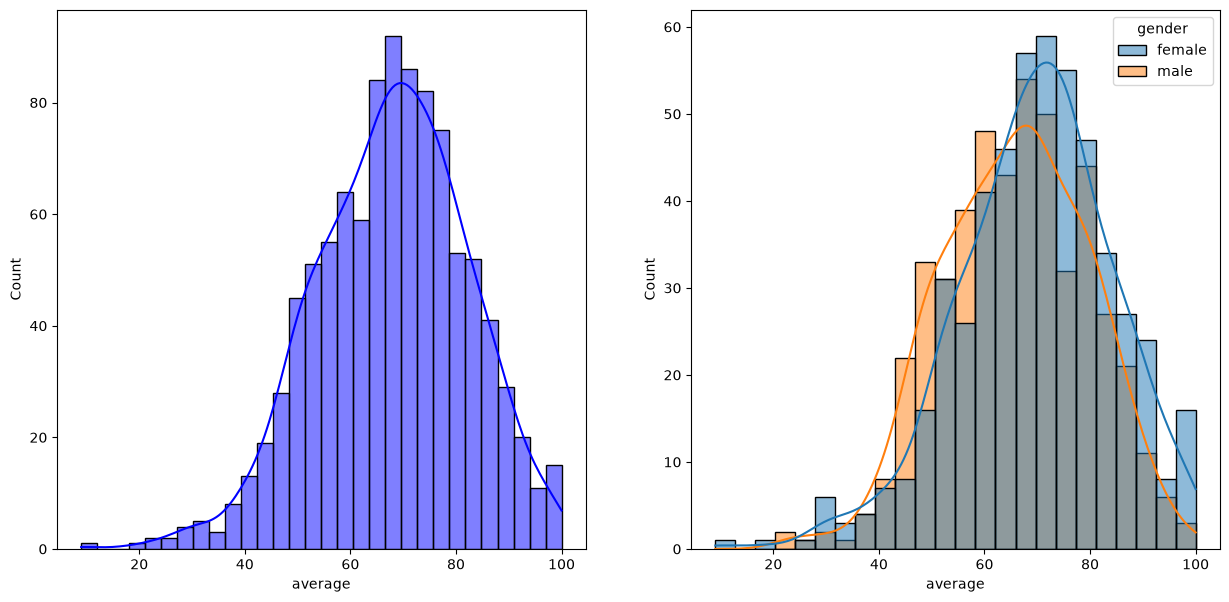

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='b')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender')
plt.show()

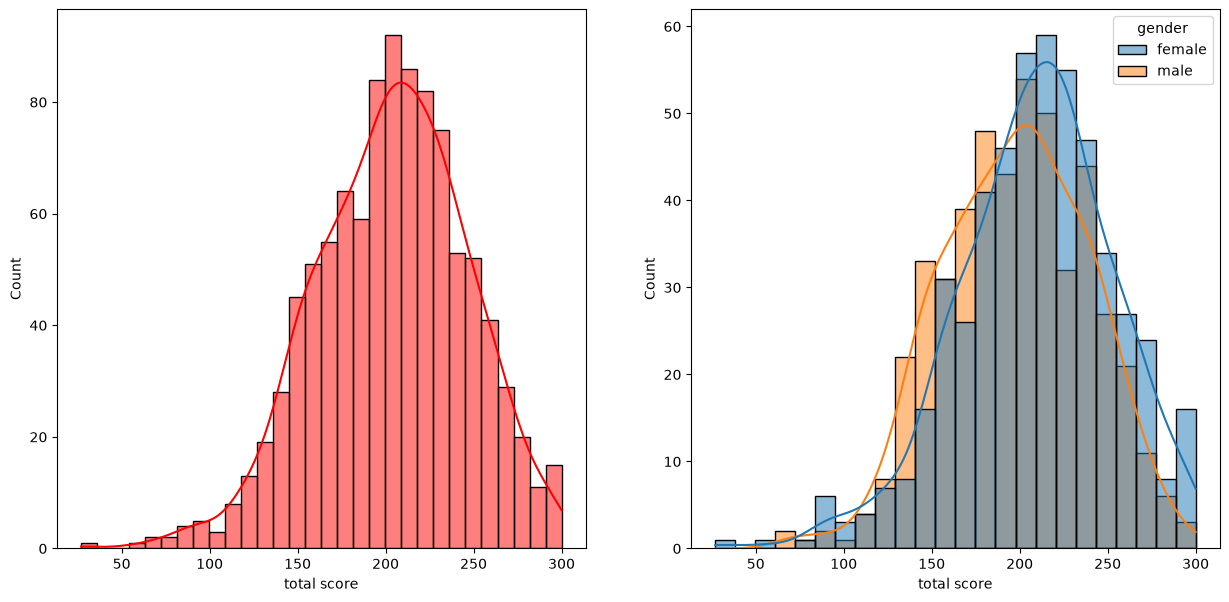

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))
plt.subplot(121)
sns.histplot(data=df,x='total score',bins=30,kde=True,color='r')
plt.subplot(122)
sns.histplot(data=df,x='total score',kde=True,hue='gender')
plt.show()

#####  Insights
- Female students tend to perform well then male students.

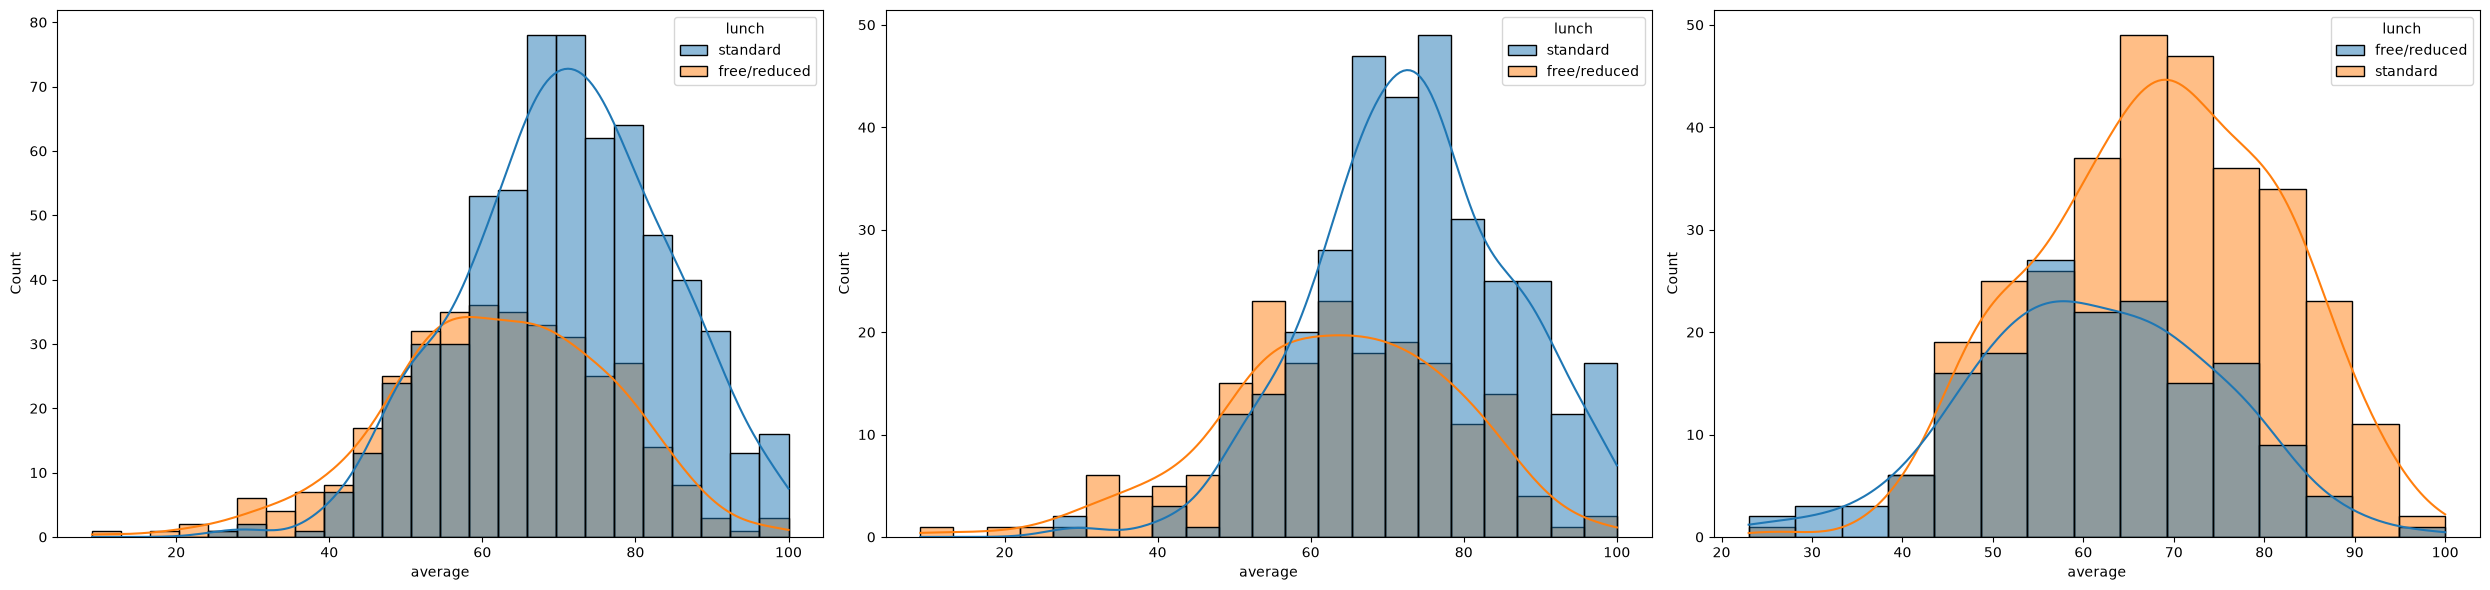

In [23]:
plt.figure(figsize=(25, 6))

plt.subplot(131)
sns.histplot(data=df, x='average', kde=True, hue='lunch')

plt.subplot(132)
sns.histplot(data=df[df['gender'] == 'female'], x='average', kde=True, hue='lunch')

plt.subplot(133)
sns.histplot(data=df[df['gender'] == 'male'], x='average', kde=True, hue='lunch')

plt.tight_layout()
plt.show()

#####  Insights
- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.

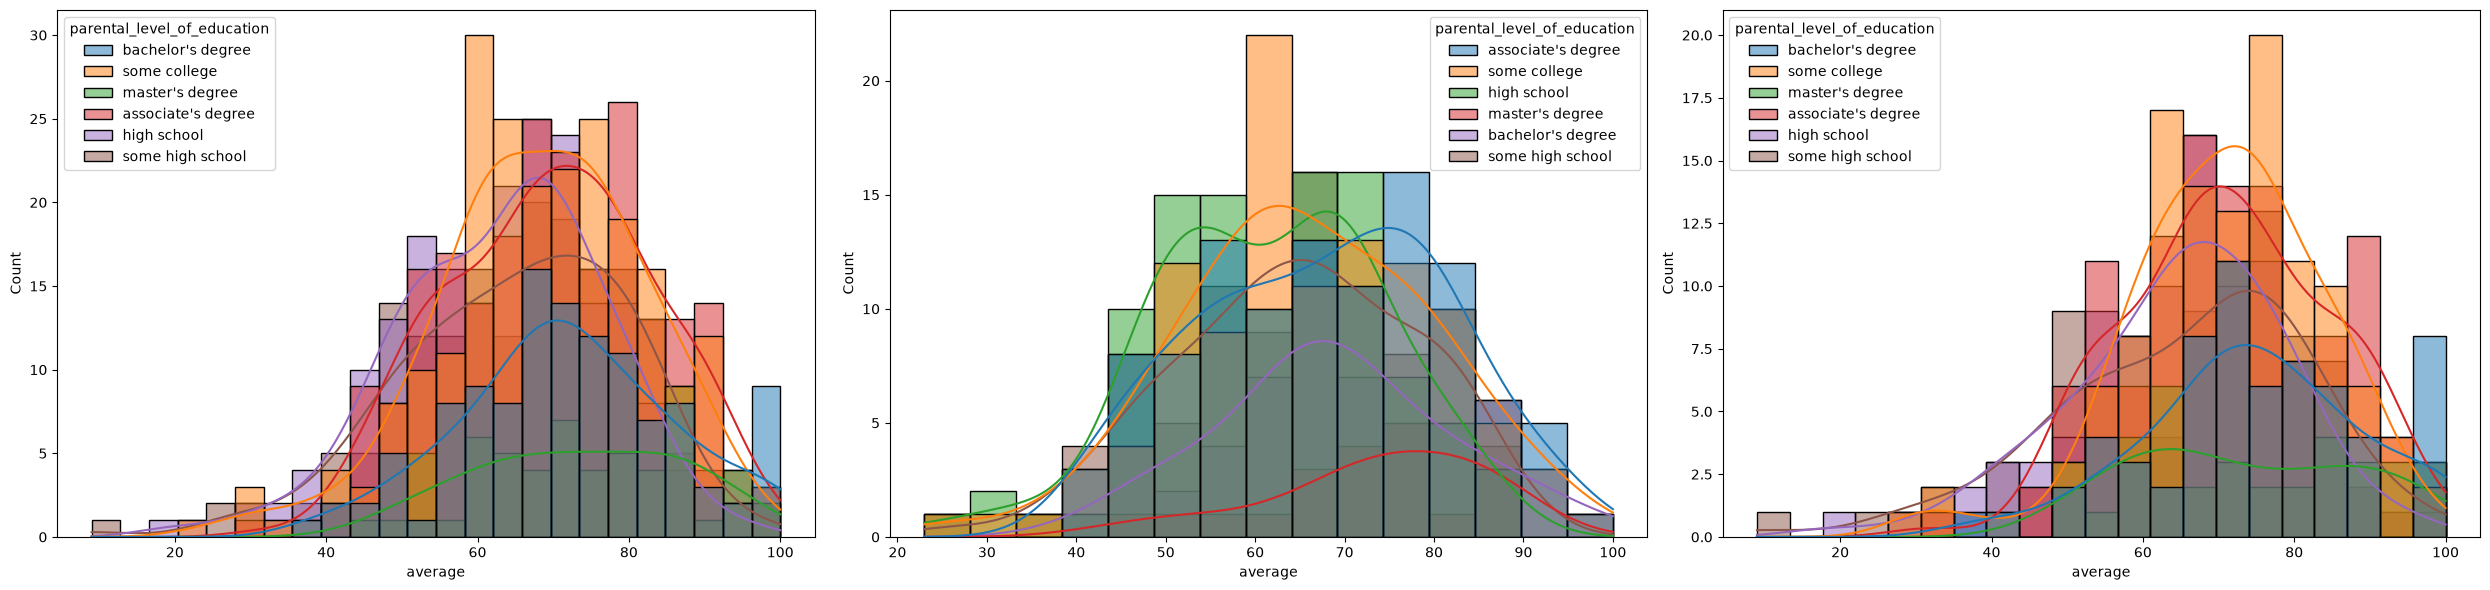

In [24]:
plt.figure(figsize=(25, 6))

plt.subplot(131)
sns.histplot(
    data=df,
    x='average',
    kde=True,
    hue='parental_level_of_education'
)

plt.subplot(132)
sns.histplot(
    data=df[df['gender'] == 'male'],
    x='average',
    kde=True,
    hue='parental_level_of_education'
)

plt.subplot(133)
sns.histplot(
    data=df[df['gender'] == 'female'],
    x='average',
    kde=True,
    hue='parental_level_of_education'
)

plt.tight_layout()
plt.show()

#####  Insights
**The graph shows the distribution of students’ average scores by parental education level:**

- **Overall:** Most students’ averages fall between approximately **50 and 85**. Students whose parents have **some college** education appear frequently across the score range.
- **Male students:** The highest concentration is around **60–75**. Students with parents holding a **master’s degree** or **associate’s degree** generally show stronger score distributions.
- **Female students:** Scores are also concentrated around **60–80**. Several groups, especially **some college** and **associate’s degree**, have higher densities in this range.
- There are some low-score outliers and a few students scoring close to **100**.

Overall, parental education appears to have **some relationship** with average scores, but the distributions overlap considerably. This graph alone does not prove that parental education causes higher performance.

In [25]:
print(df.columns.tolist())

['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score', 'total score', 'average']


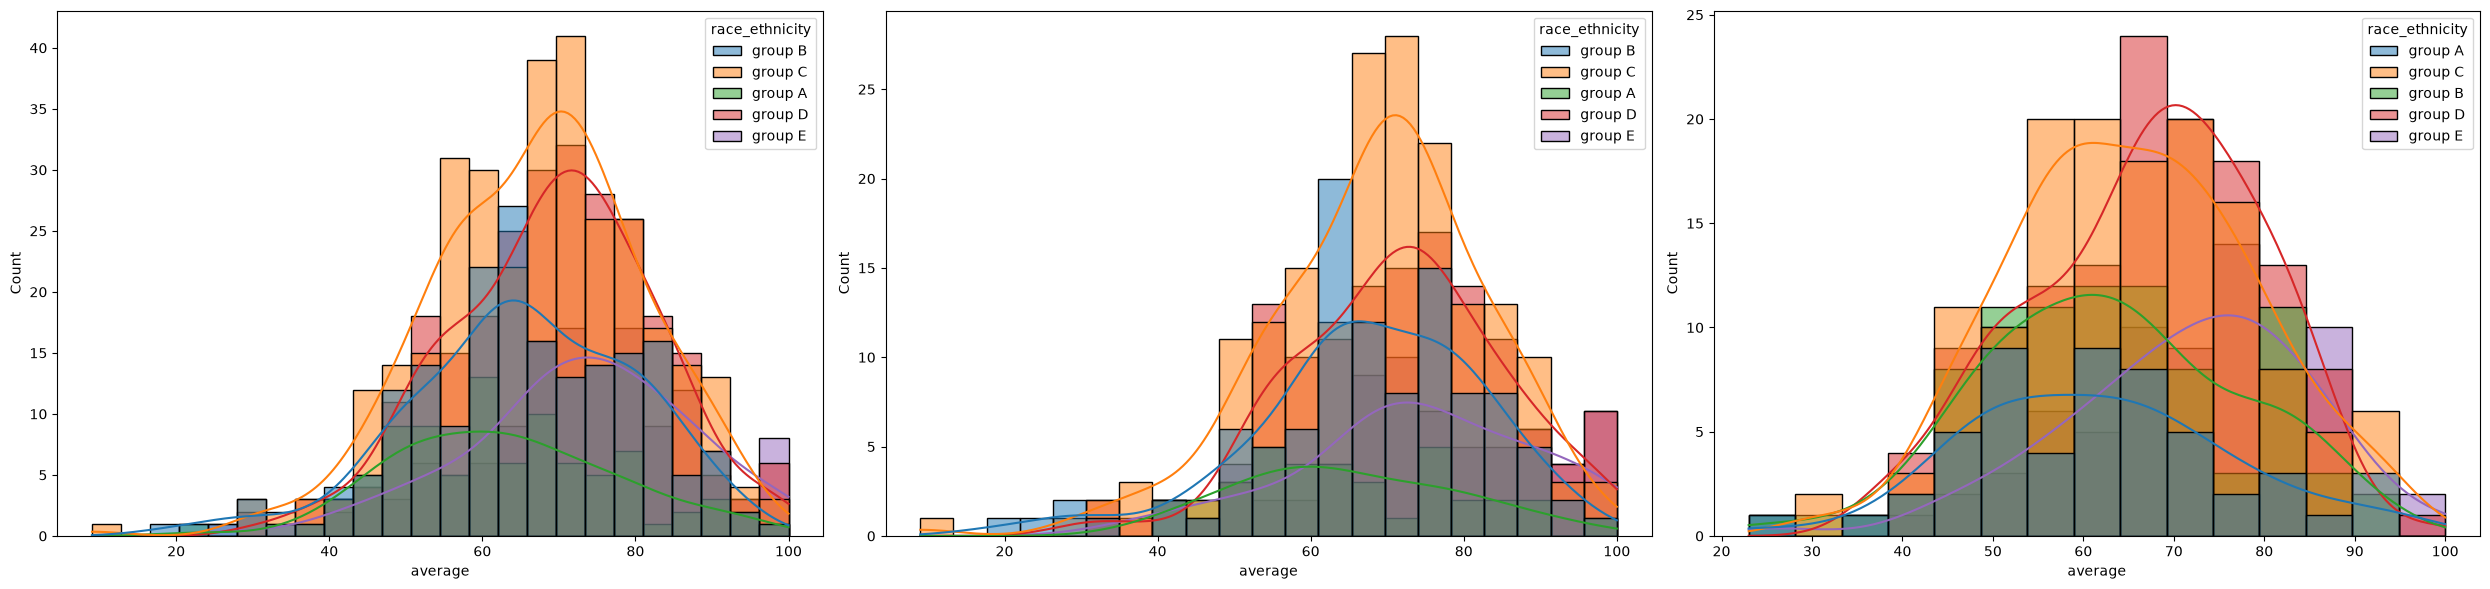

In [28]:
plt.figure(figsize=(25, 6))

plt.subplot(131)
sns.histplot(data=df, x='average', kde=True, hue='race_ethnicity')

plt.subplot(132)
sns.histplot(
    data=df[df['gender'] == 'female'],
    x='average',
    kde=True,
    hue='race_ethnicity'
)

plt.subplot(133)
sns.histplot(
    data=df[df['gender'] == 'male'],
    x='average',
    kde=True,
    hue='race_ethnicity'
)

plt.tight_layout()
plt.show()

##  Insights

**The graph compares students’ average scores by race/ethnicity:**

- **Overall:** Groups C and D have the largest number of students and are concentrated around average scores of **60–80**.
- **Group E:** Has relatively strong performance, with many scores around **70–80**.
- **Group A:** Has fewer students and generally lower average scores.
- **Male students:** Groups C and D show the strongest concentration around **65–75**.
- **Female students:** Group D tends to have higher scores, while Groups A and B show broader distributions and more lower scores.
- The distributions overlap significantly, so race/ethnicity alone does not determine performance.

These are associations shown by the data, not proof that race/ethnicity causes differences in scores.

#### 4.2 Maximumum score of students in all three subjects

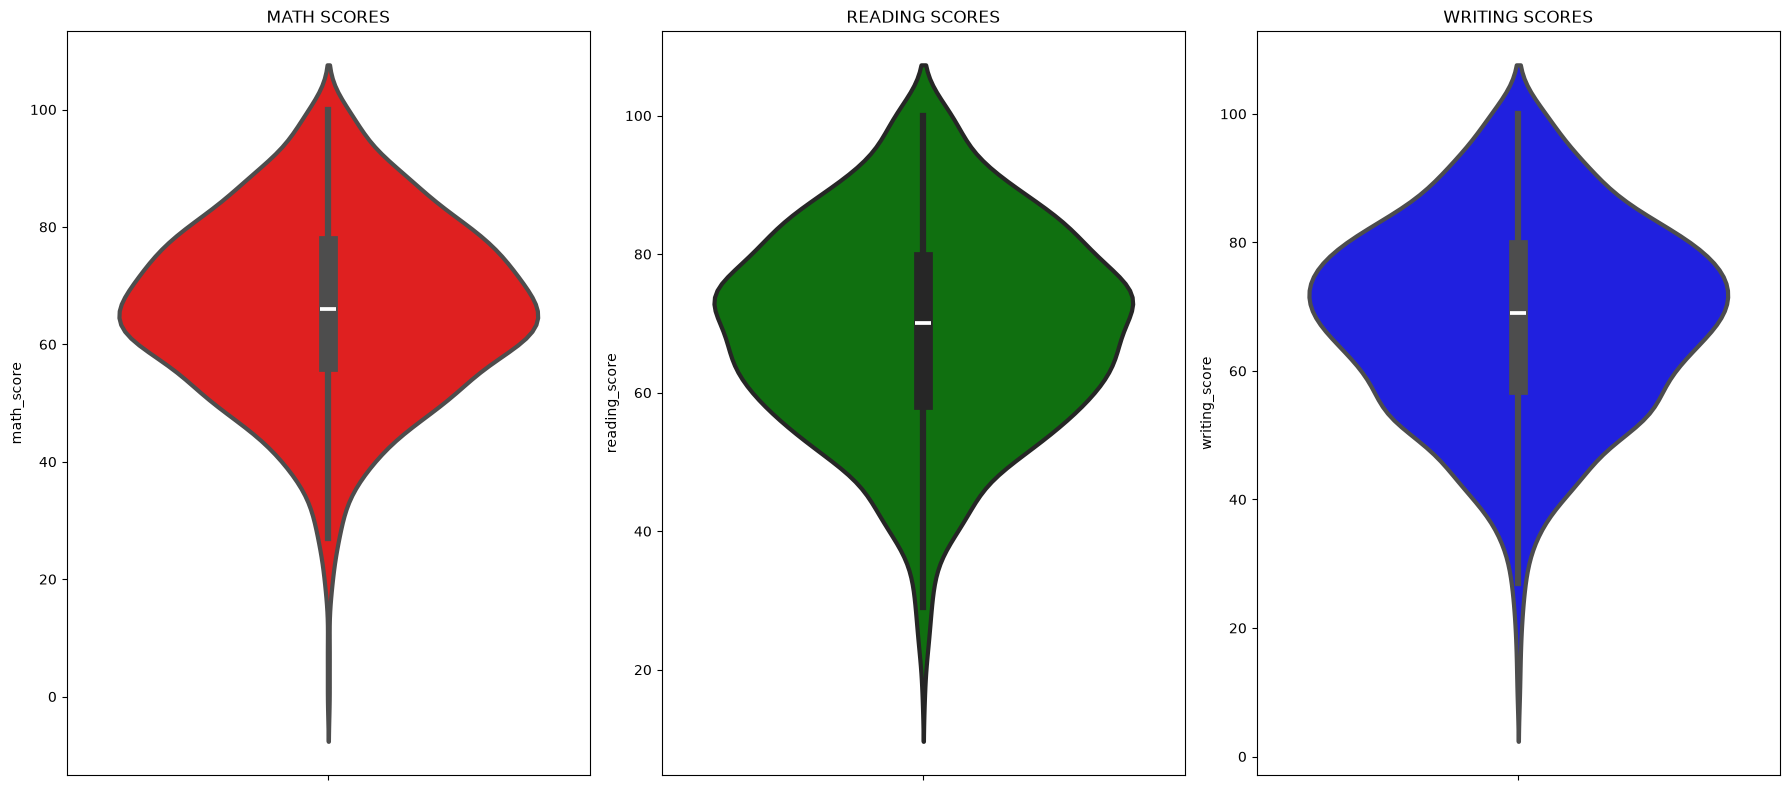

In [30]:
plt.figure(figsize=(18, 8))

plt.subplot(1, 3, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score', data=df, color='red', linewidth=3)

plt.subplot(1, 3, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score', data=df, color='green', linewidth=3)

plt.subplot(1, 3, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score', data=df, color='blue', linewidth=3)

plt.tight_layout()
plt.show()

### **Violin Plot Interpretation**

- **Math scores:** Most students score around **55–80**, with the median near **66**. The distribution is fairly broad, including some very low scores and scores near 100.
- **Reading scores:** Scores are mainly concentrated around **55–85**, with a median near **70**. This is the highest typical performance among the three subjects.
- **Writing scores:** Most scores fall between approximately **55–80**, with a median near **69**. The distribution is similar to reading but slightly wider.

The **width** of each violin represents how many students achieved a particular score range. Wider sections indicate greater concentration. Overall, students performed best in **reading**, followed by **writing**, while **math** had the lowest median and the greatest spread.

#### 4.3 Multivariate analysis using pieplot

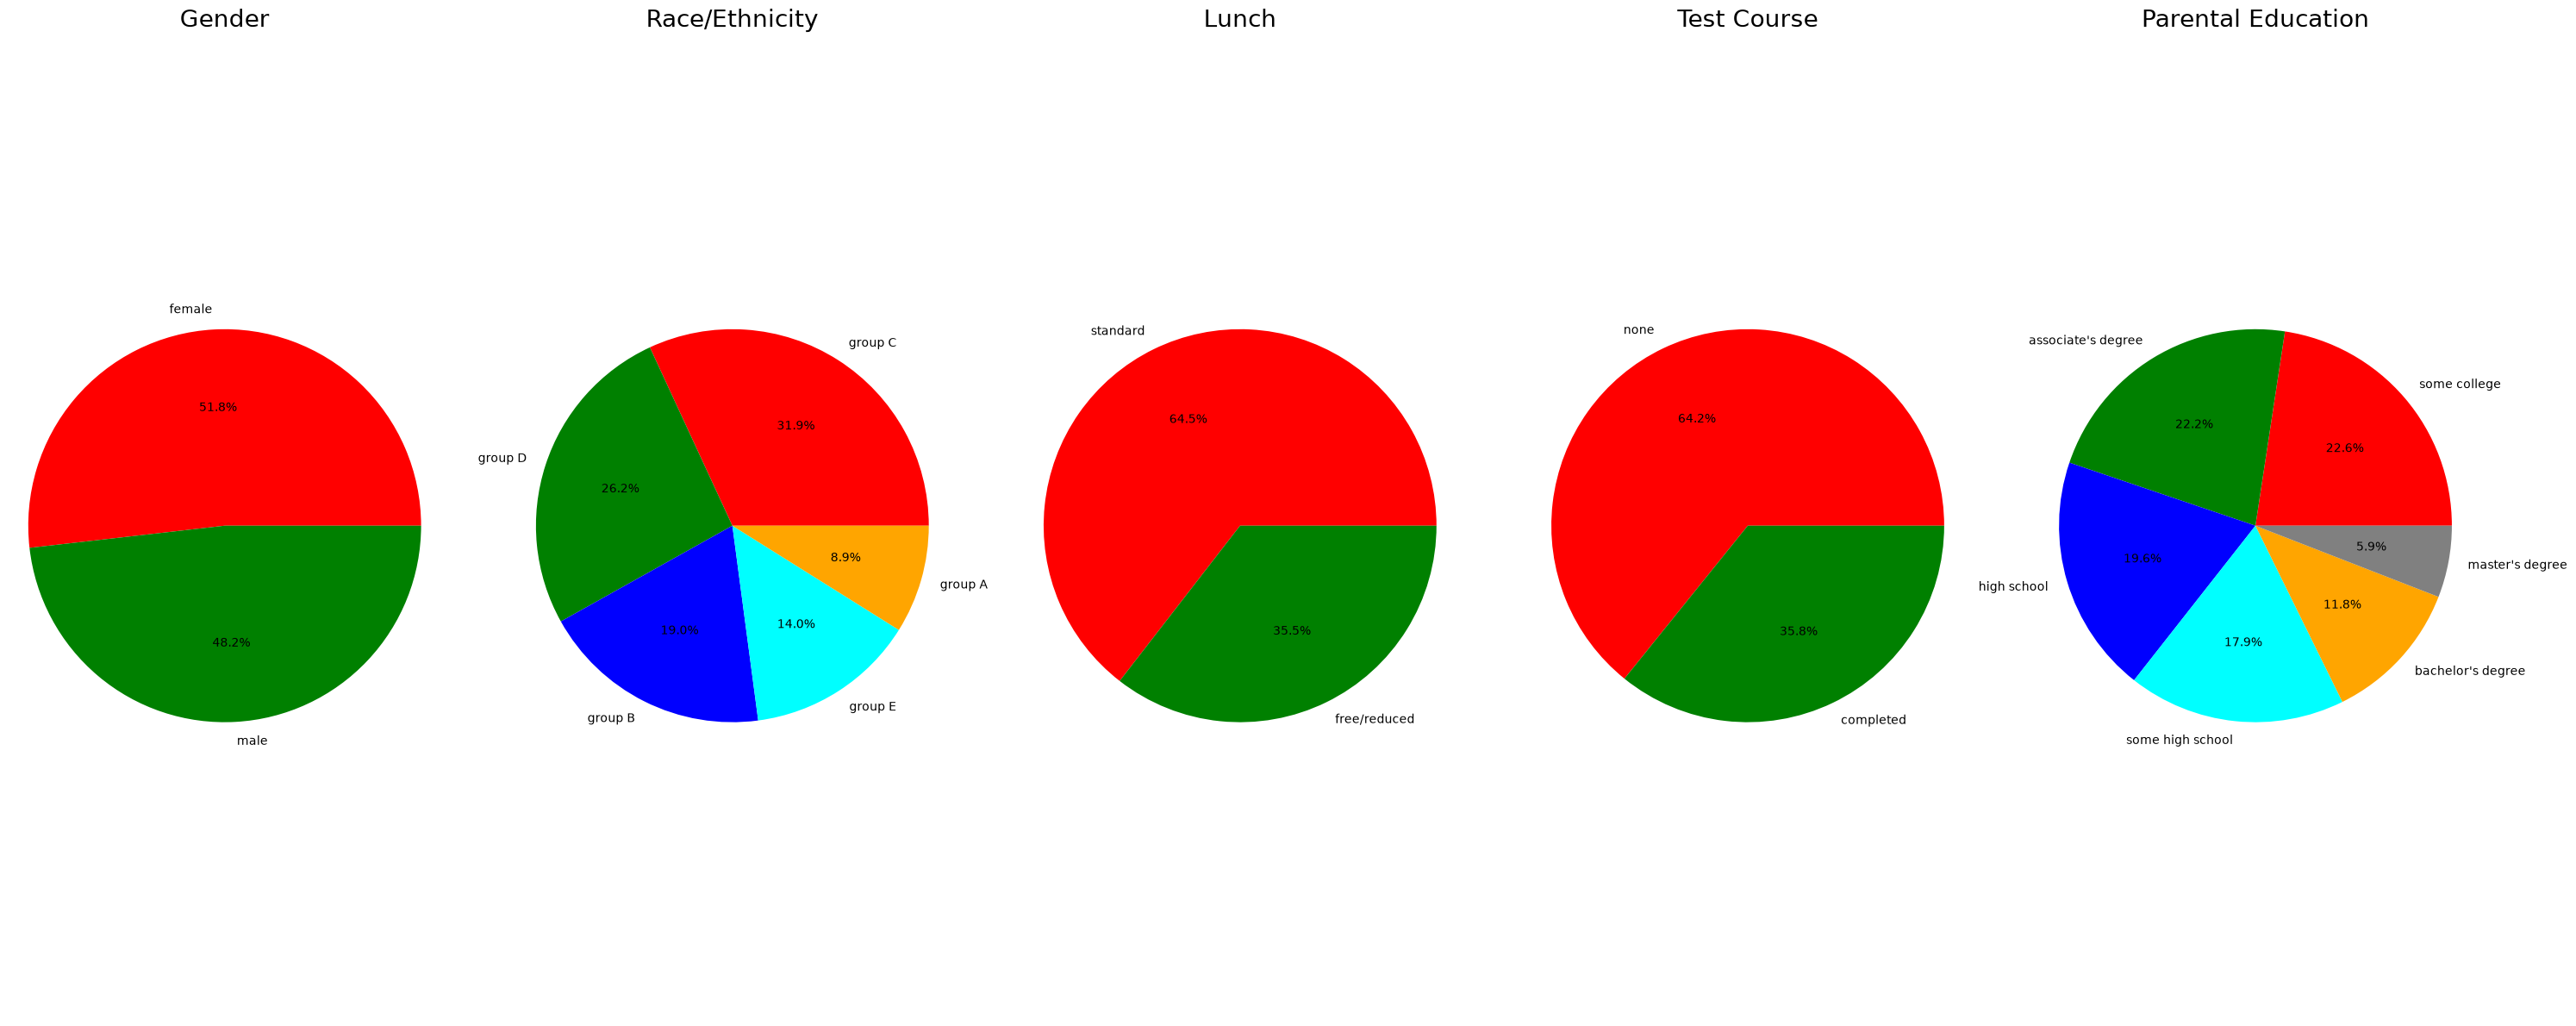

In [32]:
plt.figure(figsize=(30, 12))

columns = [
    ('gender', 'Gender', ['red', 'green']),
    ('race_ethnicity', 'Race/Ethnicity', ['red', 'green', 'blue', 'cyan', 'orange']),
    ('lunch', 'Lunch', ['red', 'green']),
    ('test_preparation_course', 'Test Course', ['red', 'green']),
    (
        'parental_level_of_education',
        'Parental Education',
        ['red', 'green', 'blue', 'cyan', 'orange', 'grey']
    )
]

for position, (column, title, colors) in enumerate(columns, start=1):
    counts = df[column].value_counts()

    plt.subplot(1, 5, position)
    plt.pie(
        counts,
        labels=counts.index,
        colors=colors,
        autopct='%.1f%%'
    )
    plt.title(title, fontsize=20)
    plt.axis('equal')

plt.tight_layout()
plt.show()

## **Pie Chart Interpretation**

- **Gender:** The number of male and female students is nearly balanced.
- **Race/Ethnicity:** Group C has the largest number of students, followed by Groups D and B. Group A has the fewest students.
- **Lunch:** Most students receive **standard lunch**; fewer receive free/reduced lunch.
- **Test preparation:** More students have **not completed** the preparation course than have completed it.
- **Parental education:** **Some college** is the most common parental education level, followed by associate’s degree and high school.

These charts describe the composition of the dataset. They show frequency, not whether a category causes higher or lower student performance.

#### 4.4 Feature Wise Visualization
#### 4.4.1 GENDER COLUMN
- How is distribution of Gender ?
- Is gender has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is distribution of Gender ? )

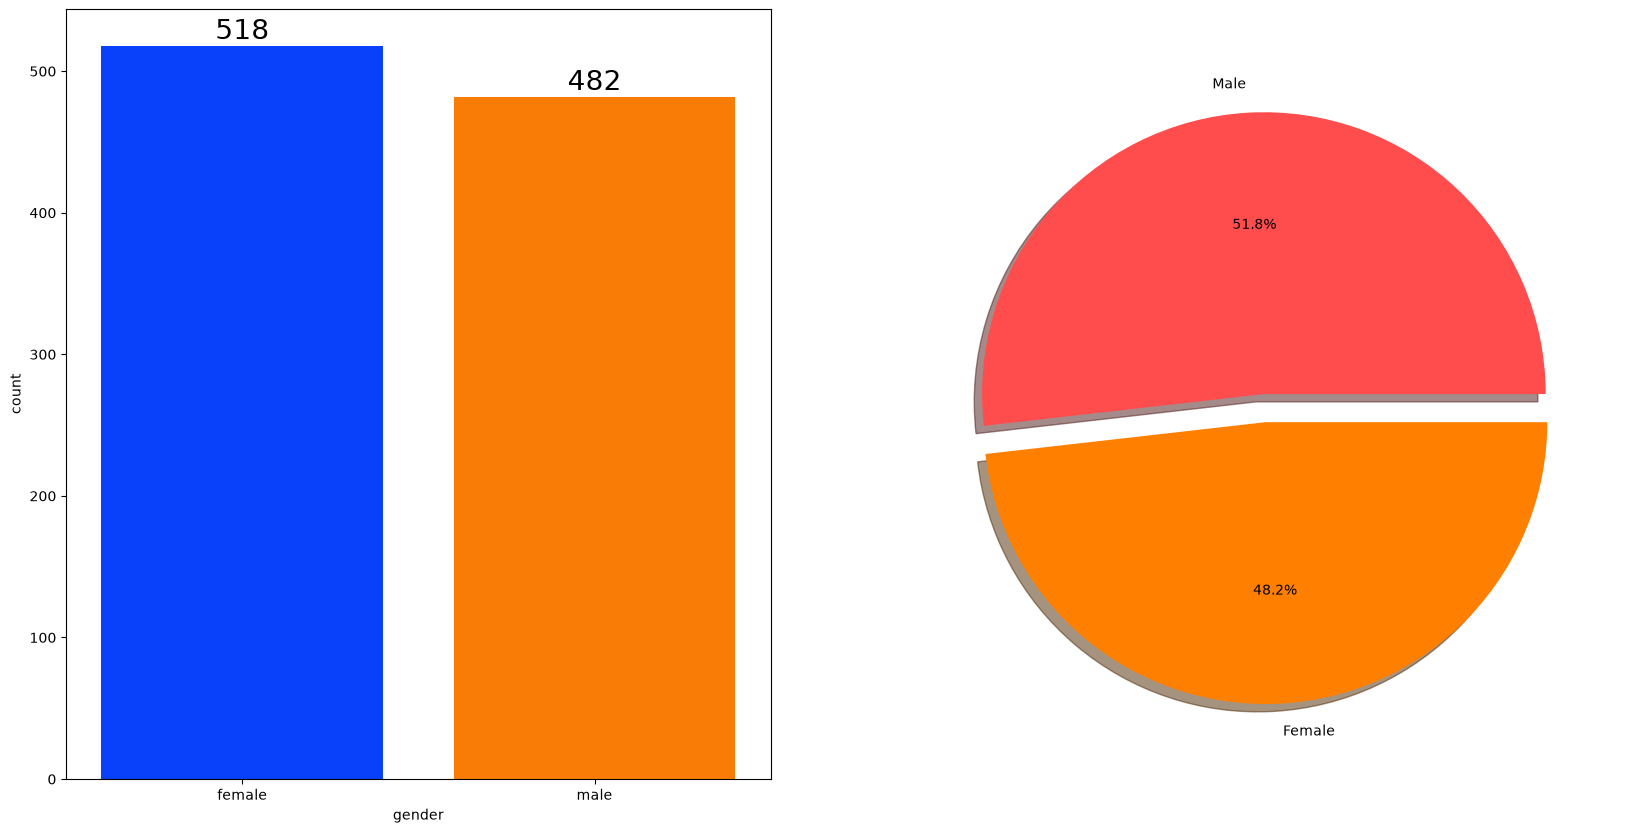

In [33]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()

#### Insights 
- Gender has balanced data with female students are 518 (48%) and male students are 482 (52%) 

#### **BIVARIATE ANALYSIS** ( Does gender has any impact on student's performance ? ) 

In [35]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math_score,reading_score,writing_score,total score,average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


In [36]:
gender_group['math_score']

gender
female    63.633205
male      68.728216
Name: math_score, dtype: float64

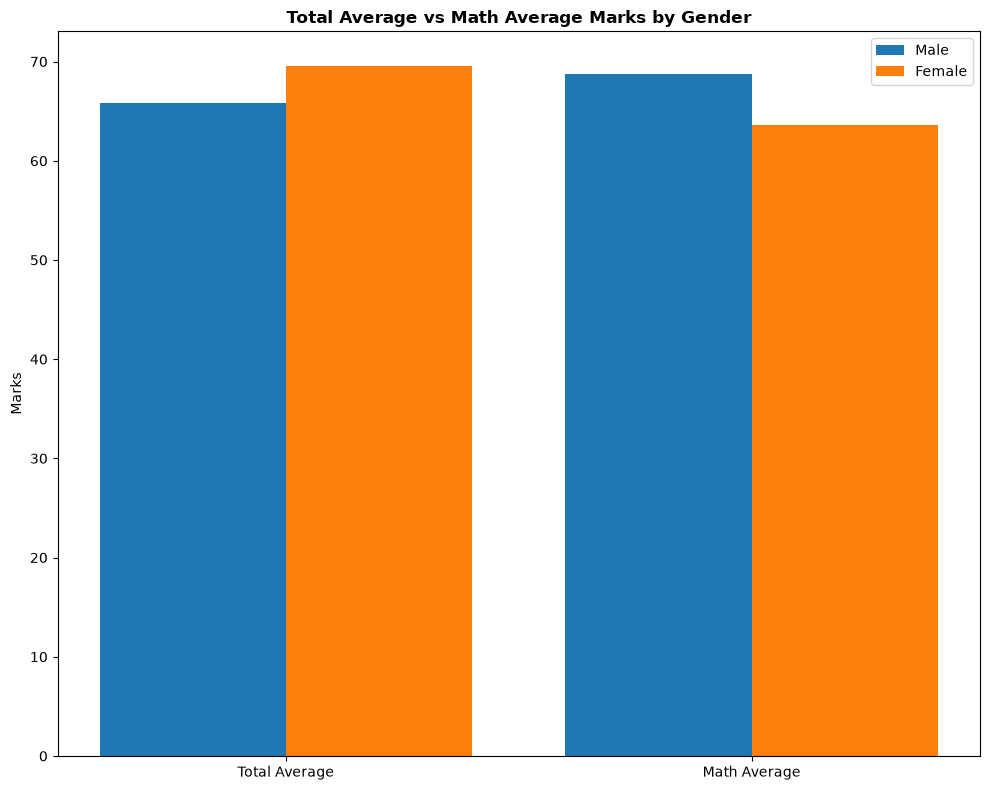

In [38]:
plt.figure(figsize=(10, 8))

categories = ['Total Average', 'Math Average']

female_scores = [
    gender_group.loc['female', 'average'],
    gender_group.loc['female', 'math_score']
]

male_scores = [
    gender_group.loc['male', 'average'],
    gender_group.loc['male', 'math_score']
]

x_axis = np.arange(len(categories))

plt.bar(x_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(x_axis + 0.2, female_scores, 0.4, label='Female')

plt.xticks(x_axis, categories)
plt.ylabel('Marks')
plt.title(
    'Total Average vs Math Average Marks by Gender',
    fontweight='bold'
)
plt.legend()
plt.tight_layout()
plt.show()

#### Insights 
- On an average females have a better overall score than men.
- whereas males has higher scores in Maths.

#### 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( How is Group wise distribution ?)

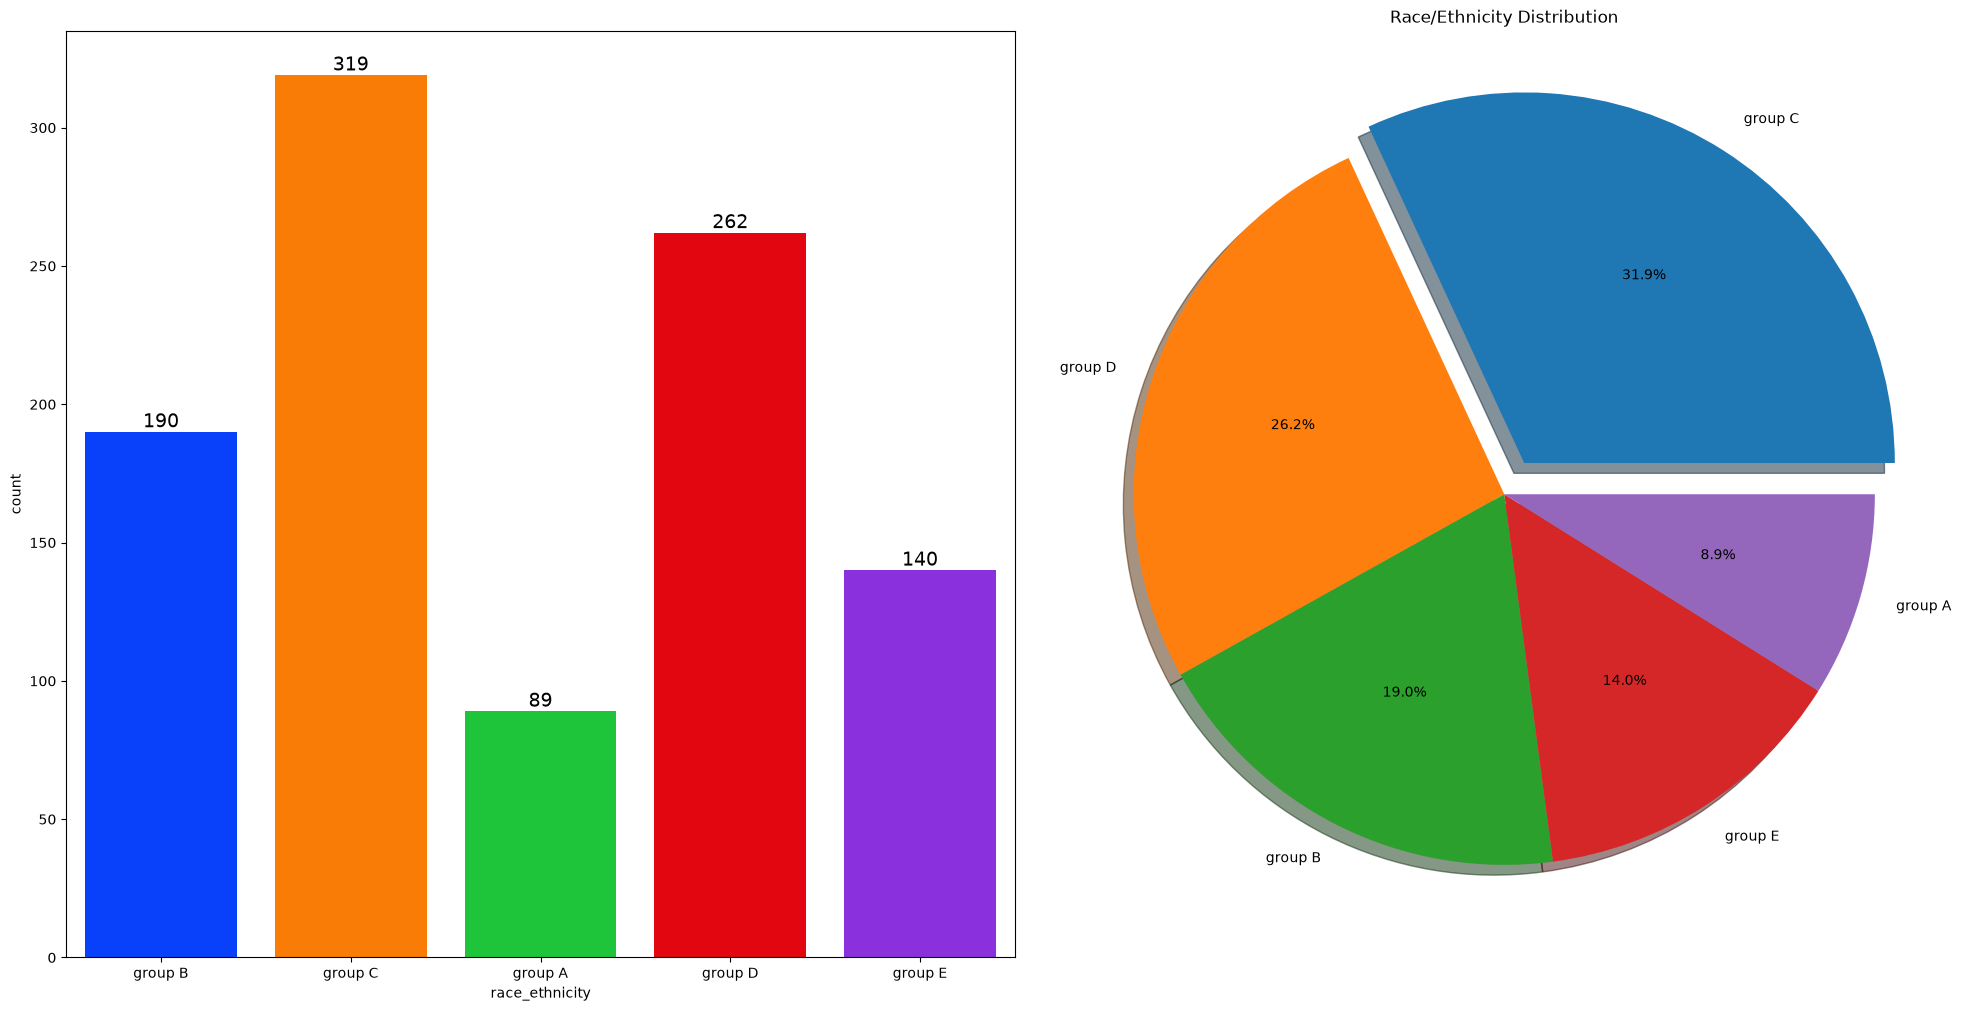

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

race_counts = df['race_ethnicity'].value_counts()

sns.countplot(
    data=df,
    x='race_ethnicity',
    palette='bright',
    ax=ax[0],
    saturation=0.95
)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=14)

ax[1].pie(
    race_counts,
    labels=race_counts.index,
    explode=[0.1, 0, 0, 0, 0],
    autopct='%1.1f%%',
    shadow=True
)
ax[1].set_title('Race/Ethnicity Distribution')

plt.tight_layout()
plt.show()

**Race/Ethnicity Distribution Interpretation**

- **Group C** has the highest number of students: **319 students (31.9%)**.
- **Group D** is the second-largest group: **262 students (26.2%)**.
- **Group B** contains **190 students (19.0%)**.
- **Group E** contains **140 students (14.0%)**.
- **Group A** has the fewest students: **89 students (8.9%)**.

Overall, Groups **C and D together represent 58.1%** of the dataset, while Group A is the least represented. This graph shows the distribution of students across groups; it does not show differences in academic performance.

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

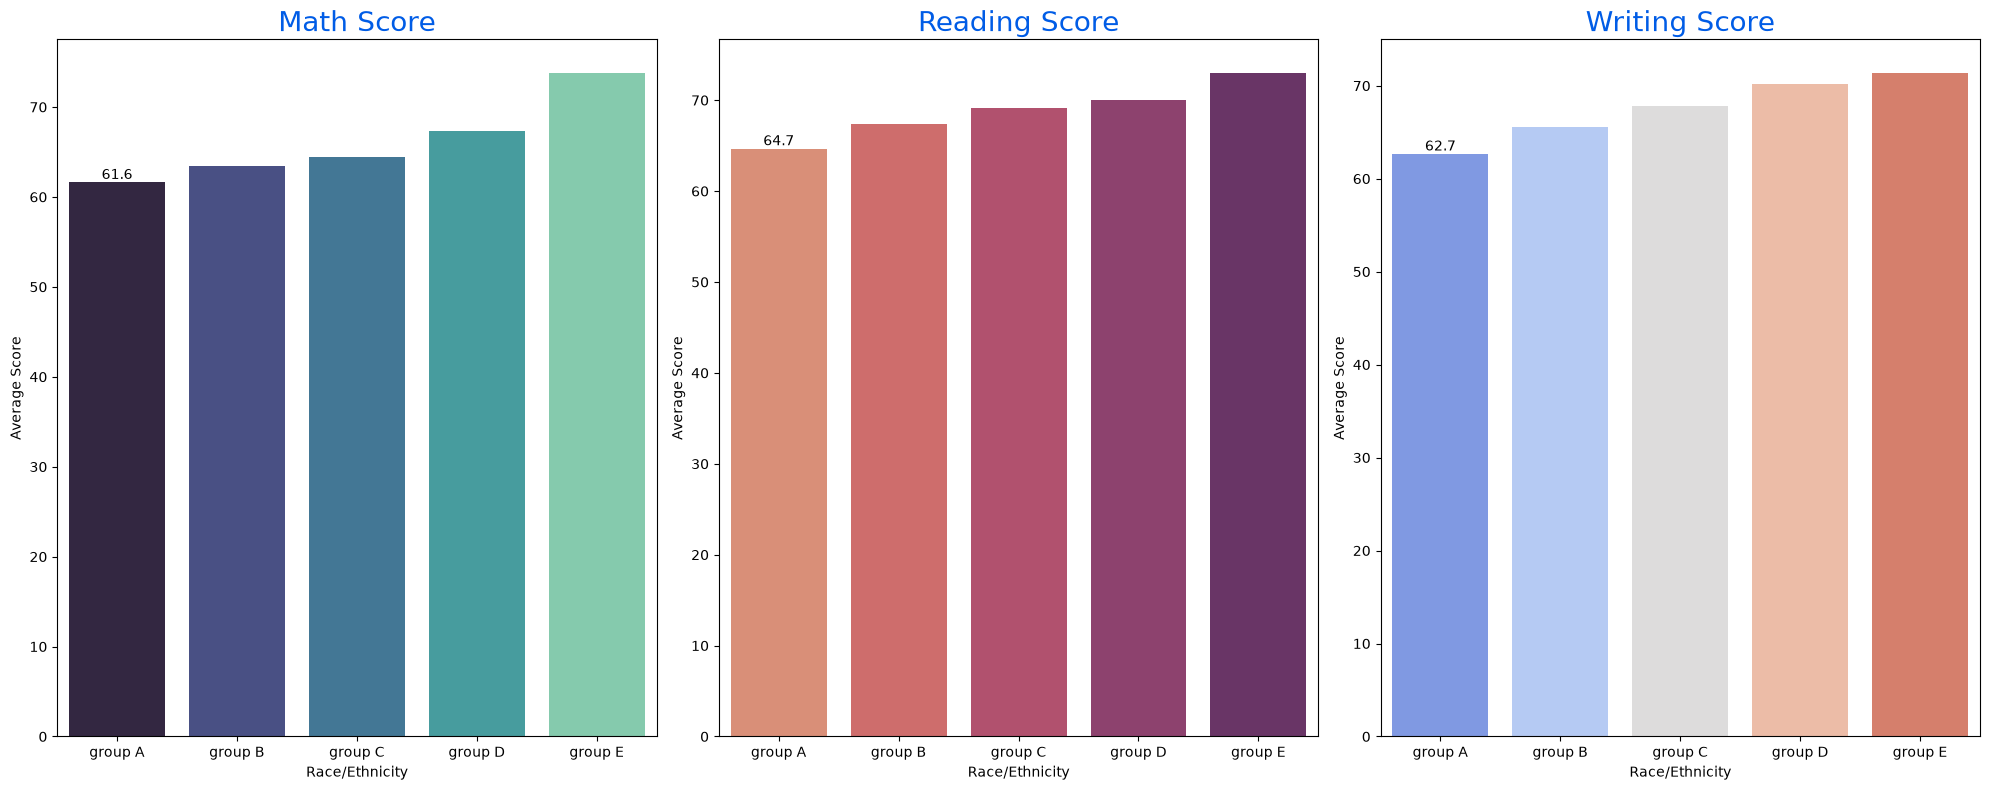

In [41]:
group_data = df.groupby('race_ethnicity')[
    ['math_score', 'reading_score', 'writing_score']
].mean()

fig, ax = plt.subplots(1, 3, figsize=(20, 8))

sns.barplot(
    x=group_data.index,
    y=group_data['math_score'],
    hue=group_data.index,
    palette='mako',
    legend=False,
    ax=ax[0]
)
ax[0].set_title('Math Score', color='#005ce6', size=20)
ax[0].set_xlabel('Race/Ethnicity')
ax[0].set_ylabel('Average Score')
ax[0].bar_label(ax[0].containers[0], fmt='%.1f')

sns.barplot(
    x=group_data.index,
    y=group_data['reading_score'],
    hue=group_data.index,
    palette='flare',
    legend=False,
    ax=ax[1]
)
ax[1].set_title('Reading Score', color='#005ce6', size=20)
ax[1].set_xlabel('Race/Ethnicity')
ax[1].set_ylabel('Average Score')
ax[1].bar_label(ax[1].containers[0], fmt='%.1f')

sns.barplot(
    x=group_data.index,
    y=group_data['writing_score'],
    hue=group_data.index,
    palette='coolwarm',
    legend=False,
    ax=ax[2]
)
ax[2].set_title('Writing Score', color='#005ce6', size=20)
ax[2].set_xlabel('Race/Ethnicity')
ax[2].set_ylabel('Average Score')
ax[2].bar_label(ax[2].containers[0], fmt='%.1f')

plt.tight_layout()
plt.show()

**Average Scores by Race/Ethnicity**

- **Group E** performs best overall:
  - Highest math average, approximately **74**
  - Highest reading average, approximately **73**
  - Highest writing average, approximately **71**
- **Group A** has the lowest average scores:
  - Math: approximately **62**
  - Reading: approximately **65**
  - Writing: approximately **63**
- **Groups B, C, and D** show moderate performance.
- Reading scores are generally higher than math and writing scores across all groups.
- Writing scores are relatively close to reading scores, especially for Groups D and E.

Overall, the chart suggests that Group E students achieved the highest average marks in all three subjects, while Group A students achieved the lowest. However, these are group-level associations and do not imply that race/ethnicity causes the performance differences.

#### 4.4.3 PARENTAL LEVEL OF EDUCATION COLUMN
- What is educational background of student's parent ?
- Is parental education has any impact on student's performance ?

#### UNIVARIATE ANALYSIS ( What is educational background of student's parent ? )

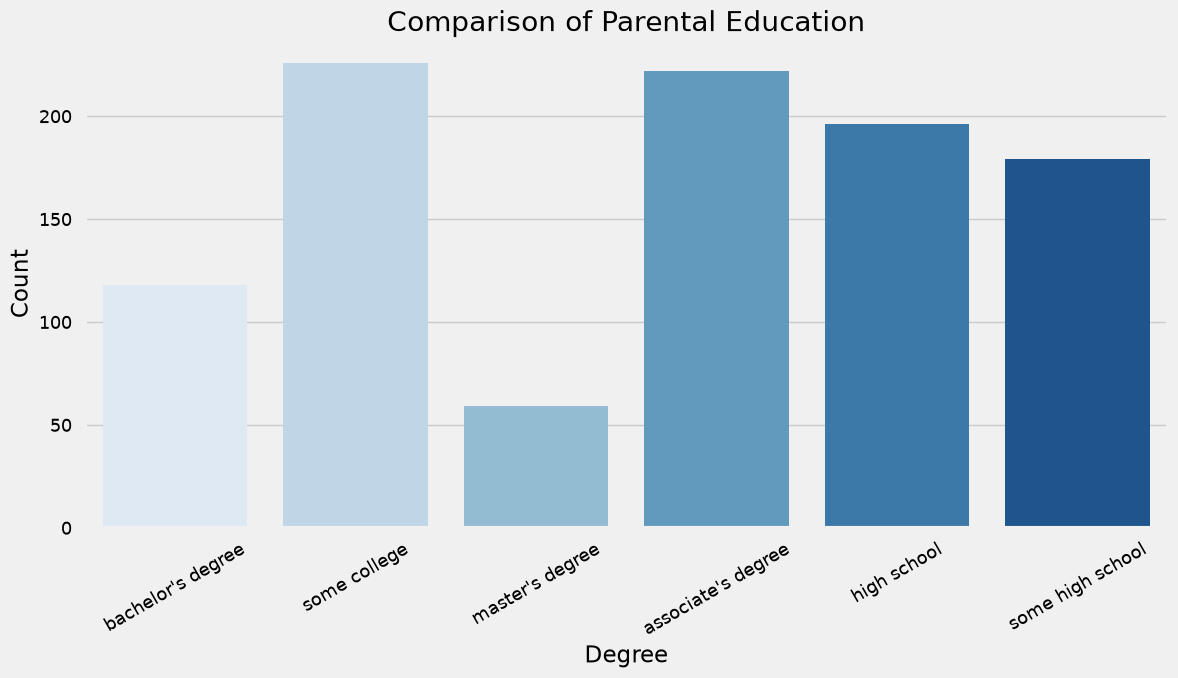

In [48]:
plt.figure(figsize=(12, 7))
plt.style.use('fivethirtyeight')

sns.countplot(
    data=df,
    x='parental_level_of_education',
    palette='Blues'
)

plt.title('Comparison of Parental Education', fontsize=20)
plt.xlabel('Degree')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### Insights 
- Largest number of parents are from some college.

#### BIVARIATE ANALYSIS ( Is parental education has any impact on student's performance ? )

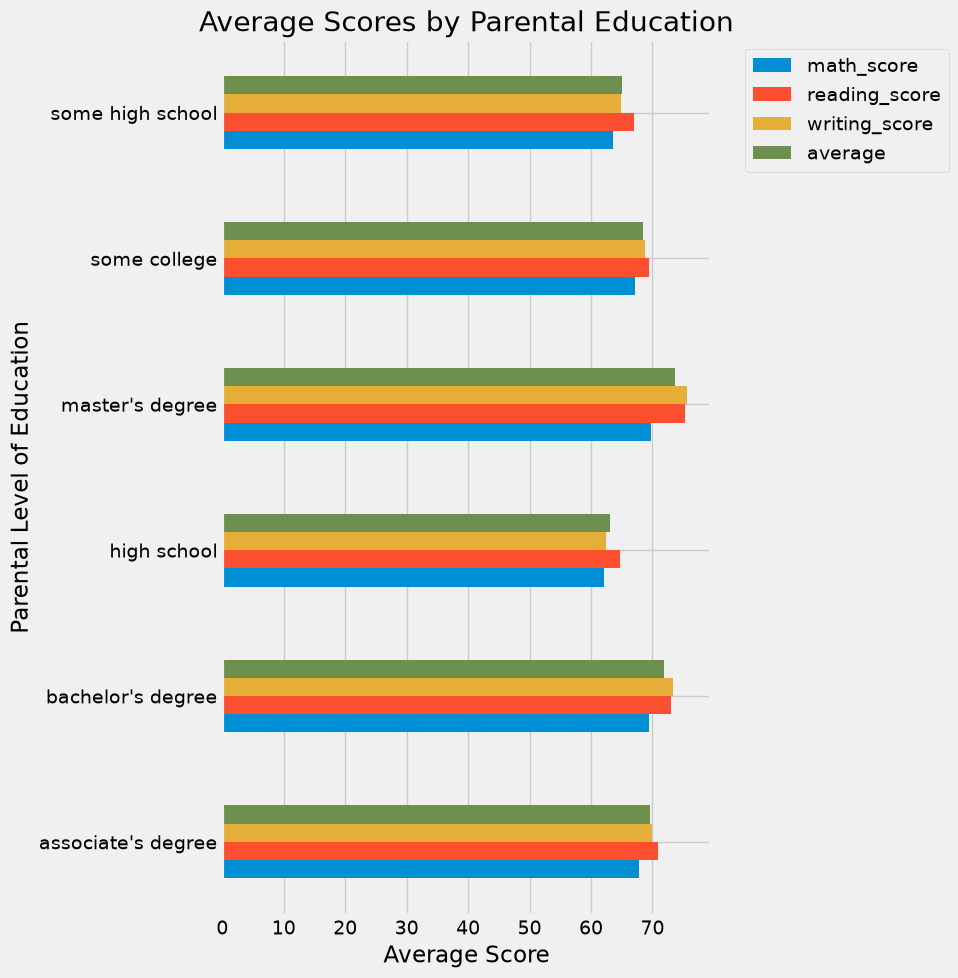

In [45]:
parental_group = (
    df.groupby('parental_level_of_education')
    [['math_score', 'reading_score', 'writing_score', 'average']]
    .mean()
)

parental_group.plot(kind='barh', figsize=(10, 10))

plt.xlabel('Average Score')
plt.ylabel('Parental Level of Education')
plt.title('Average Scores by Parental Education')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Insights 
- The score of student whose parents possess master and bachelor level education are higher than others.

#### 4.4.4 LUNCH COLUMN 
- Which type of lunch is most common amoung students ?
- What is the effect of lunch type on test results?


#### UNIVARIATE ANALYSIS ( Which type of lunch is most common amoung students ? )

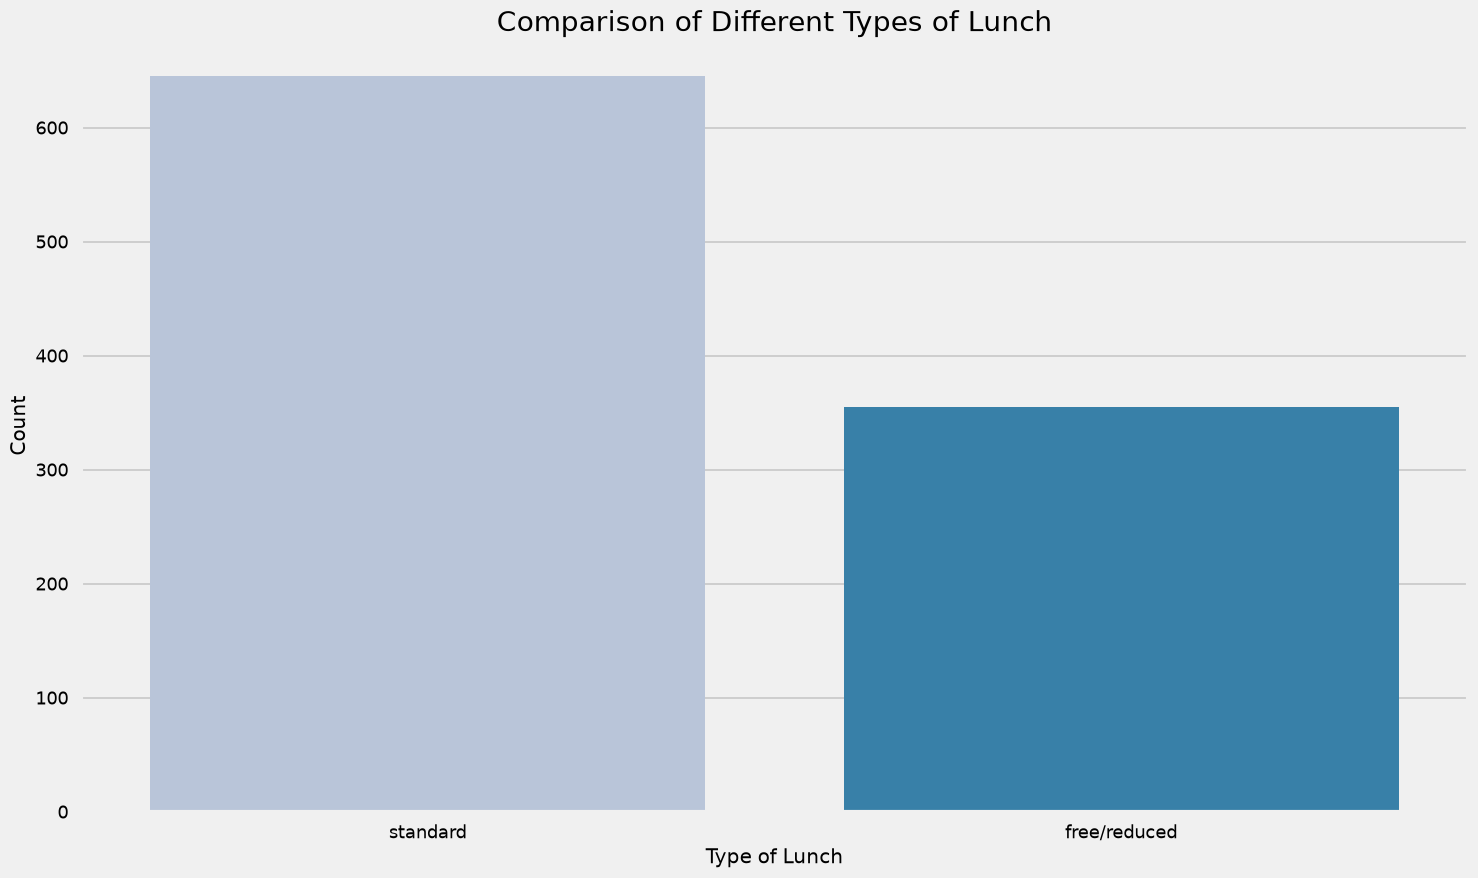

In [47]:
plt.figure(figsize=(15, 9))
plt.style.use('seaborn-v0_8-talk')

sns.countplot(
    data=df,
    x='lunch',
    palette='PuBu'
)

plt.title('Comparison of Different Types of Lunch', fontsize=20)
plt.xlabel('Type of Lunch')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

#### Insights 
- Students being served Standard lunch was more than free lunch

#### BIVARIATE ANALYSIS (  Is lunch type intake has any impact on student's performance ? )

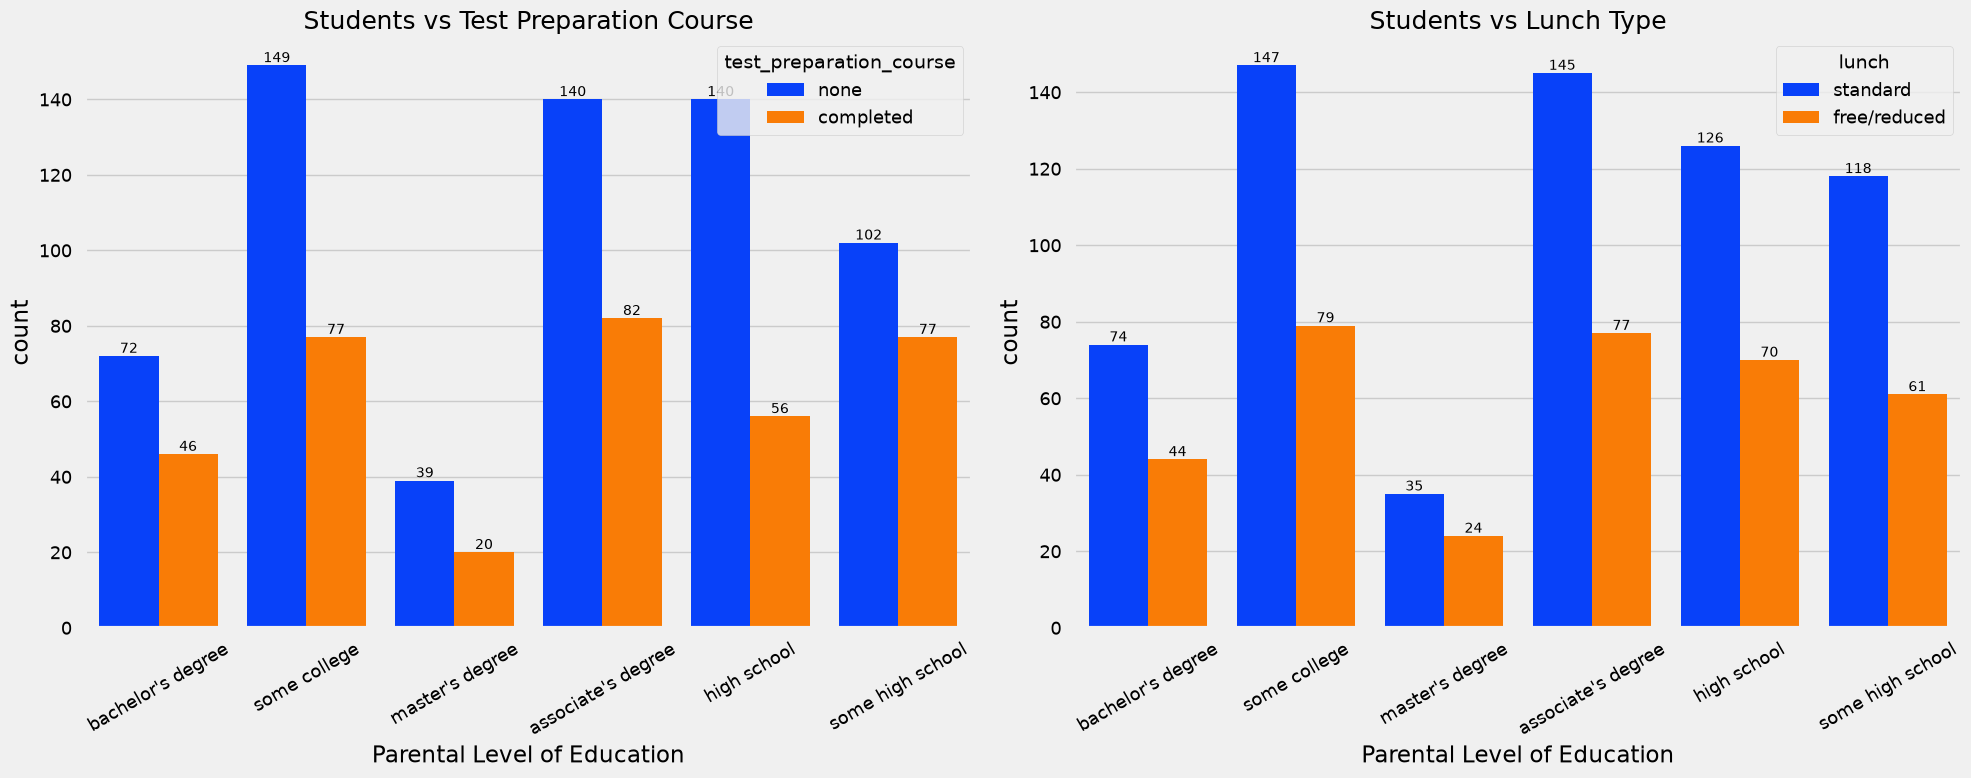

In [50]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

sns.countplot(
    data=df,
    x='parental_level_of_education',
    hue='test_preparation_course',
    palette='bright',
    saturation=0.95,
    ax=ax[0]
)
ax[0].set_title('Students vs Test Preparation Course', fontsize=18)
ax[0].set_xlabel('Parental Level of Education')
ax[0].tick_params(axis='x', rotation=30)

for container in ax[0].containers:
    ax[0].bar_label(container, color='black', fontsize=10)

sns.countplot(
    data=df,
    x='parental_level_of_education',
    hue='lunch',
    palette='bright',
    saturation=0.95,
    ax=ax[1]
)
ax[1].set_title('Students vs Lunch Type', fontsize=18)
ax[1].set_xlabel('Parental Level of Education')
ax[1].tick_params(axis='x', rotation=30)

for container in ax[1].containers:
    ax[1].bar_label(container, color='black', fontsize=10)

plt.tight_layout()
plt.show()

**Graph Interpretation**

The graphs show how parental education relates to test preparation and lunch type.

**Test preparation course:**

- In every parental education category, more students have **not completed** the preparation course than have completed it.
- The largest number of students belongs to the **some college** group: 149 did not complete the course and 77 completed it.
- Students whose parents have an **associate’s degree** also have relatively high participation: 82 completed the course.
- The **master’s degree** group has the fewest students overall.

**Lunch type:**

- In every parental education category, **standard lunch** is more common than free/reduced lunch.
- Standard lunch is most common among students whose parents have **some college** education, followed by an **associate’s degree**.
- Free/reduced lunch is also highest in the some college group because that group contains more students overall.

Overall, the charts describe category counts. They do not directly show students’ scores or prove that parental education causes differences in test preparation or lunch type.

#### 4.4.5 TEST PREPARATION COURSE COLUMN 
- Which type of lunch is most common amoung students ?
- Is Test prepration course has any impact on student's performance ?

#### BIVARIATE ANALYSIS ( Is Test prepration course has any impact on student's performance ? )

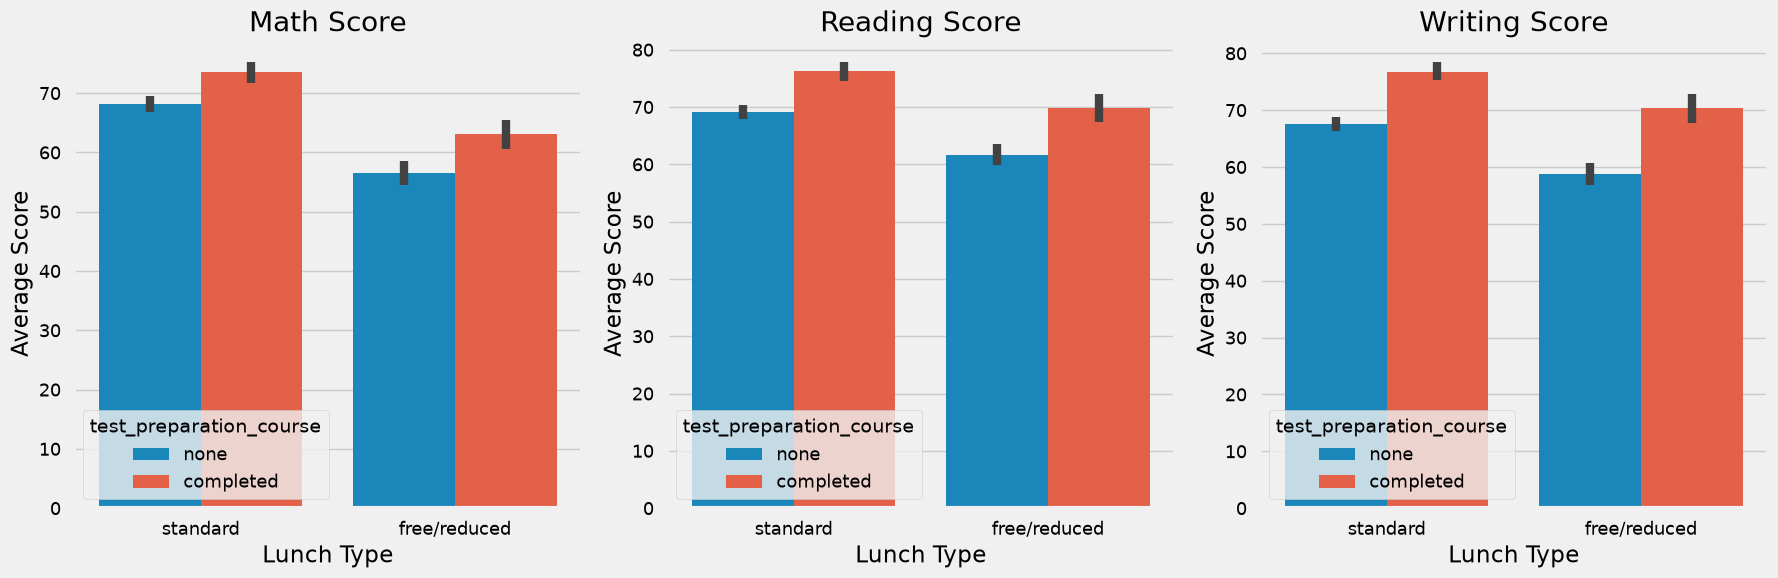

In [52]:
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

sns.barplot(
    data=df,
    x='lunch',
    y='math_score',
    hue='test_preparation_course',
    ax=ax[0]
)
ax[0].set_title('Math Score')
ax[0].set_xlabel('Lunch Type')
ax[0].set_ylabel('Average Score')

sns.barplot(
    data=df,
    x='lunch',
    y='reading_score',
    hue='test_preparation_course',
    ax=ax[1]
)
ax[1].set_title('Reading Score')
ax[1].set_xlabel('Lunch Type')
ax[1].set_ylabel('Average Score')

sns.barplot(
    data=df,
    x='lunch',
    y='writing_score',
    hue='test_preparation_course',
    ax=ax[2]
)
ax[2].set_title('Writing Score')
ax[2].set_xlabel('Lunch Type')
ax[2].set_ylabel('Average Score')

plt.tight_layout()
plt.show()

**Interpretation**

The charts compare average subject scores by lunch type and test preparation status.

- Students who **completed the test preparation course** scored higher than those who did not in **math, reading, and writing**.
- Students with **standard lunch** scored higher than students with **free/reduced lunch** in both preparation groups.
- The highest scores occur among students with **standard lunch who completed** the preparation course:
  - Math: approximately **74**
  - Reading: approximately **76**
  - Writing: approximately **76**
- The lowest scores occur among students with **free/reduced lunch who did not complete** the course:
  - Math: approximately **56**
  - Reading: approximately **62**
  - Writing: approximately **59**
- The preparation-course advantage appears particularly large for **reading and writing**.

Overall, the graph shows an association between lunch type, test preparation, and academic performance. It does not prove that lunch type or course completion directly causes higher scores.

#### 4.4.6 CHECKING OUTLIERS

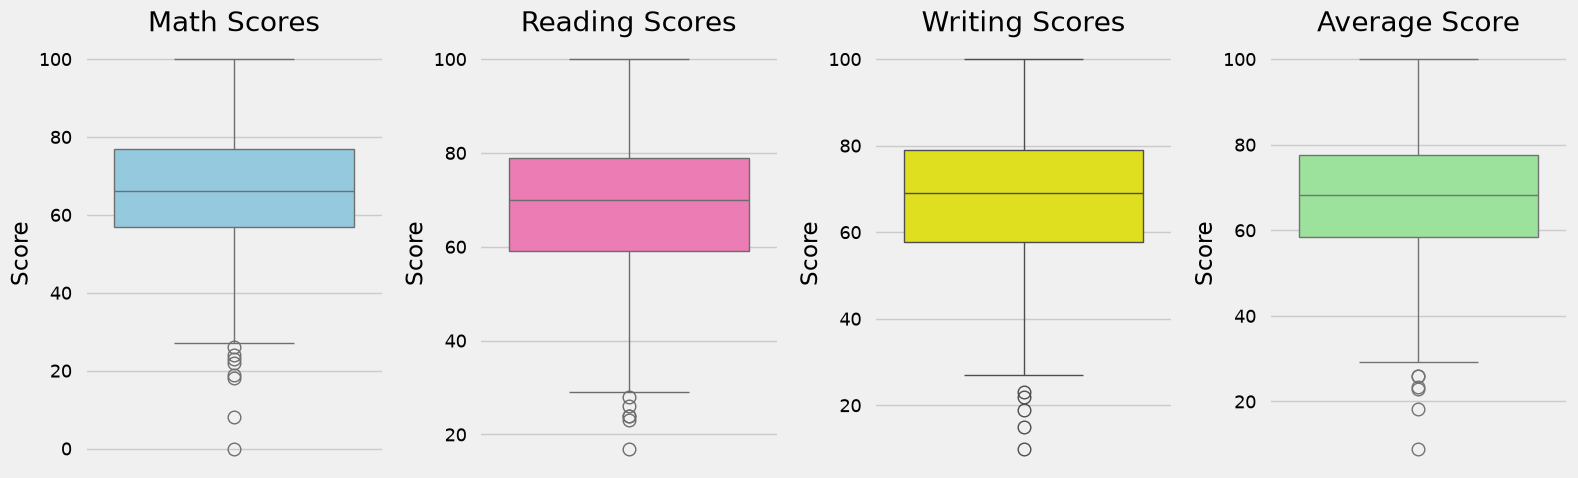

In [54]:
fig, ax = plt.subplots(1, 4, figsize=(16, 5))

sns.boxplot(y=df['math_score'], color='skyblue', ax=ax[0])
ax[0].set_title('Math Scores')
ax[0].set_ylabel('Score')

sns.boxplot(y=df['reading_score'], color='hotpink', ax=ax[1])
ax[1].set_title('Reading Scores')
ax[1].set_ylabel('Score')

sns.boxplot(y=df['writing_score'], color='yellow', ax=ax[2])
ax[2].set_title('Writing Scores')
ax[2].set_ylabel('Score')

sns.boxplot(y=df['average'], color='lightgreen', ax=ax[3])
ax[3].set_title('Average Score')
ax[3].set_ylabel('Score')

plt.tight_layout()
plt.show()

**Box Plot Interpretation**

- **Math scores:** Median is approximately **66**. Most scores lie between **57 and 77**, with several low-score outliers, including scores near **0**.
- **Reading scores:** Median is approximately **69**. Most scores lie between **59 and 78**, with a few low outliers between about **17 and 28**.
- **Writing scores:** Median is approximately **68**. Most scores lie between **58 and 79**, with several low outliers, including scores below **25**.
- **Average score:** Median is approximately **68**. Most averages lie between **58 and 77**, with a few low outliers.

Overall, reading has the highest median score, followed closely by writing and then math. The middle 50% of scores are fairly similar across subjects, but math and writing contain several unusually low values. The dots below the whiskers represent outliers, not necessarily errors.

#### 4.4.7 MUTIVARIATE ANALYSIS USING PAIRPLOT

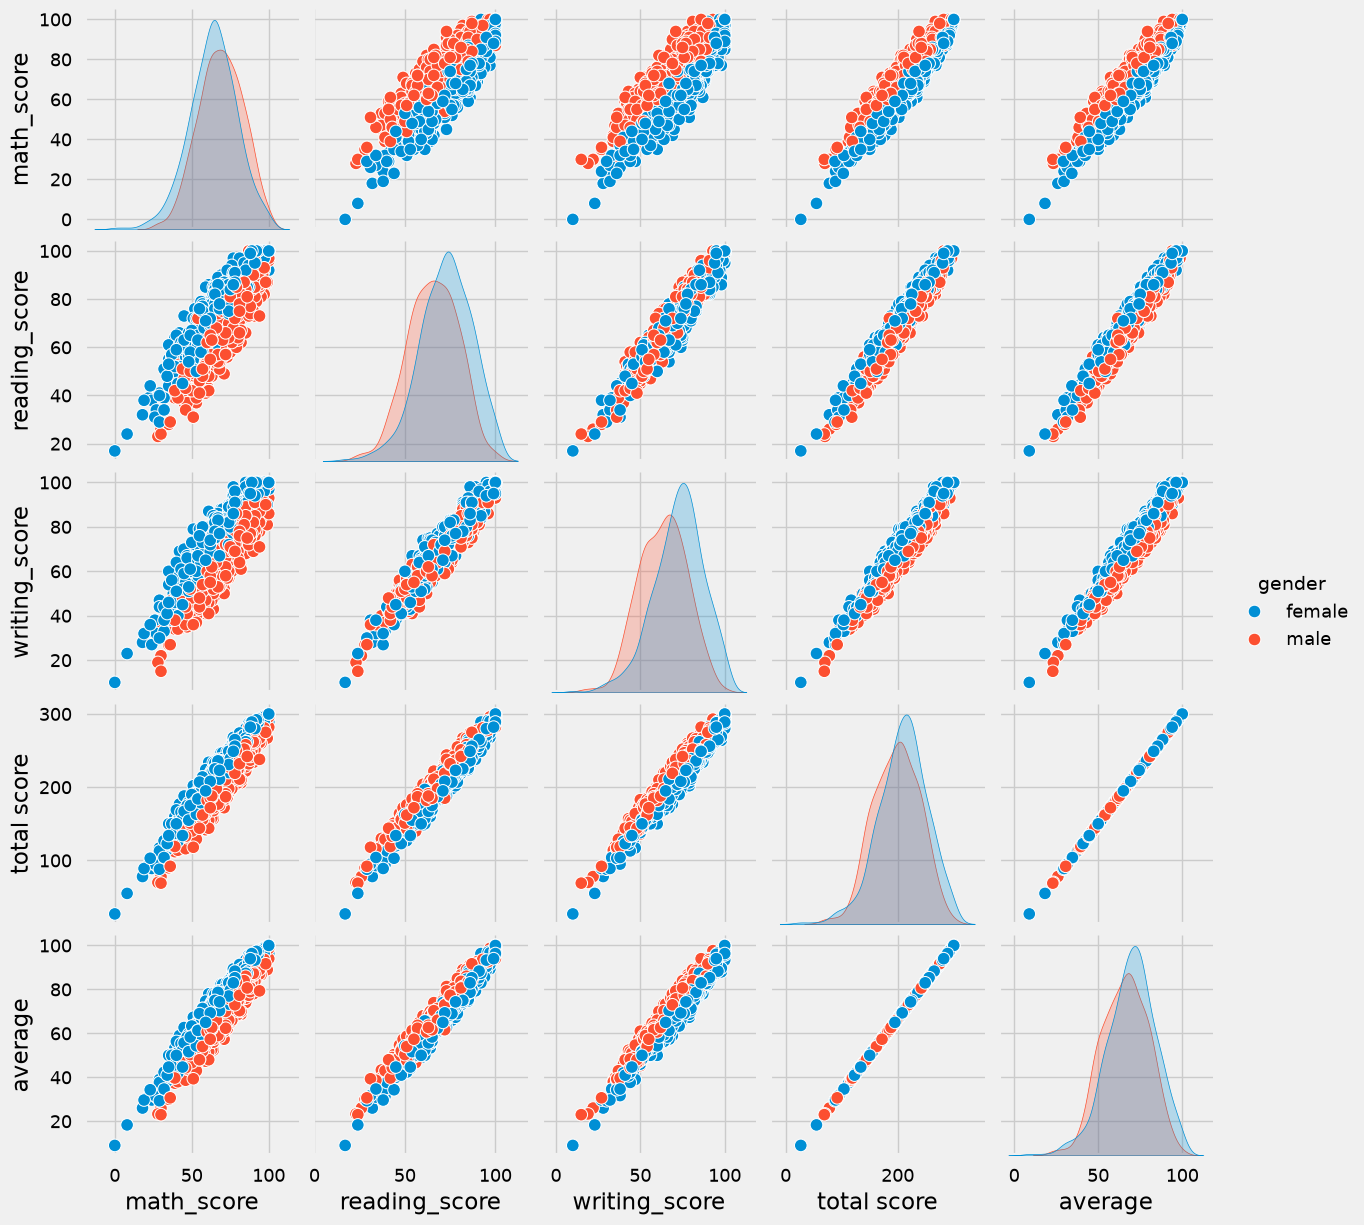

In [55]:
sns.pairplot(df,hue = 'gender')
plt.show()

**Pair Plot Interpretation**

- All three subject scores show a strong positive linear relationship.
- Students with higher math scores generally also have higher reading and writing scores.
- The `total_score` and `average` variables are almost perfectly correlated with the individual subject scores because they were calculated from them.
- Female students generally show slightly higher reading and writing scores.
- Male students appear slightly stronger in math in some areas.
- The distributions on the diagonal show that scores are mostly concentrated between approximately **50 and 85**.
- A few students have unusually low scores, visible near the lower-left areas of the plots.

Overall, performance in one subject is a good indicator of performance in the other subjects. However, the pair plot shows correlation, not causation.

## **5. Conclusions**

- The dataset contains **1,000 students** with no missing values or duplicate records.
- Male and female students are represented in nearly equal numbers.
- Groups **C and D** contain the largest number of students, while Group A is the smallest group.
- Most students receive **standard lunch**, and most have not completed the test preparation course.
- Students with standard lunch generally achieve higher scores than students with free/reduced lunch.
- Students who completed the test preparation course generally perform better in all three subjects.
- Reading has the highest average score, followed by writing and math.
- Group E has the highest average performance, while Group A has the lowest.
- Math, reading, and writing scores have a strong positive relationship: students who perform well in one subject usually perform well in the others.
- Some low-score outliers are present, especially in math.

Overall, lunch type, test preparation, parental education, and race/ethnicity are associated with student performance in this dataset. These findings show relationships, but they do not prove that any single factor directly causes higher or lower scores.